# optimize_behavior_analysis_compare_methods

## 目的
`trial_best` の Arrow ファイルを使って、**全最適化手法（GPR / CMA-ES / Random / GA）** をまとめて比較する notebook です。

## この notebook で行うこと
- 手法ごとの `info` / `pop` データを読み込む
- **表として比較**する
- **手法ごとの主図**を個別に出力する
- **全手法を並べた主図**をまとめて出力する
- 比較表と画像を保存する

## 主図の内容
- 左軸: 各 `info_label` の **total shared ratio**
- 右軸: **population of taking selfish action**


## 事前準備

必要なら先に以下を実行してください。

```bash
pip install polars pyarrow matplotlib
```


In [26]:
from pathlib import Path
import math
import polars as pl
import matplotlib.pyplot as plt


In [27]:
# ===== ここを必要に応じて変更 =====
BASE_DIR = Path(".")
NETWORK_NAME = "ba_1000"     # "ba_1000" / "facebook" / "wiki-vote"
METHODS = ["gpr", "cmaes", "random", "ga"]
IDENTIFIER = "trial_best"

TOTAL_AGENTS_MAP = {
    "ba_1000": 1000,
    "facebook": 4039,
    "wiki-vote": 7115,
}

INFO_LABEL_MAP = {
    0: "misinformation",
    1: "corrective",
    2: "observational",
    3: "behavior-guiding",
}

METHOD_LABEL_MAP = {
    "gpr": "GPR",
    "cmaes": "CMA-ES",
    "random": "Random",
    "ga": "GA",
}

TOTAL_AGENTS = TOTAL_AGENTS_MAP[NETWORK_NAME]

# 保存先
OUTPUT_DIR = BASE_DIR / f"optimize_behavior_{NETWORK_NAME}_compare"
SAVE_TABLES = True
SAVE_INDIVIDUAL_FIGURES = True
SAVE_COMBINED_FIGURE = True

OUTPUT_DIR


PosixPath('optimize_behavior_ba_1000_compare')

In [28]:
def build_method_tables(method_name: str):
    result_dir = BASE_DIR / f"optimize_test_{NETWORK_NAME}" / method_name / "result"
    pop_path = result_dir / f"{IDENTIFIER}_pop.arrow"
    info_path = result_dir / f"{IDENTIFIER}_info.arrow"

    if not pop_path.exists():
        raise FileNotFoundError(f"pop.arrow が見つかりません: {pop_path}")
    if not info_path.exists():
        raise FileNotFoundError(f"info.arrow が見つかりません: {info_path}")

    pop_df = pl.read_ipc(pop_path, memory_map=False)
    info_df = pl.read_ipc(info_path, memory_map=False)

    # --- pop ---
    pop_time_df = (
        pop_df
        .select(["num_iter", "t", "num_selfish"])
        .with_columns(
            (pl.col("num_selfish") / TOTAL_AGENTS).alias("selfish_ratio")
        )
        .sort(["num_iter", "t"])
    )

    pop_final_df = (
        pop_time_df
        .group_by("num_iter")
        .agg(pl.all().sort_by("t").last())
        .sort("num_iter")
    )

    pop_time_mean_df = (
        pop_time_df
        .group_by("t")
        .agg([
            pl.col("num_selfish").mean().alias("mean_num_selfish"),
            pl.col("selfish_ratio").mean().alias("mean_selfish_ratio"),
            pl.col("selfish_ratio").std().alias("std_selfish_ratio"),
        ])
        .sort("t")
    )

    # --- info ---
    info_time_mean_df = (
        info_df
        .lazy()
        .group_by([pl.col("t"), pl.col("info_label")])
        .agg([
            pl.col("num_posted").mean().alias("num_posted"),
            pl.col("num_received").mean().alias("num_received"),
            pl.col("num_shared").mean().alias("num_shared"),
            pl.col("num_viewed").mean().alias("num_viewed"),
            pl.col("num_fst_viewed").mean().alias("num_fst_viewed"),
        ])
        .sort(["info_label", "t"])
        .with_columns([
            pl.col("num_posted").cum_sum().over("info_label").alias("total_num_posted"),
            pl.col("num_received").cum_sum().over("info_label").alias("total_num_received"),
            pl.col("num_shared").cum_sum().over("info_label").alias("total_num_shared"),
            pl.col("num_viewed").cum_sum().over("info_label").alias("total_num_viewed"),
            pl.col("num_fst_viewed").cum_sum().over("info_label").alias("total_num_fst_viewed"),
        ])
        .collect()
        .with_columns([
            pl.col("info_label").replace_strict(INFO_LABEL_MAP).alias("info_name"),
            (pl.col("total_num_shared") / TOTAL_AGENTS).alias("shared_ratio"),
            (pl.col("total_num_viewed") / TOTAL_AGENTS).alias("viewed_ratio"),
            (pl.col("total_num_fst_viewed") / TOTAL_AGENTS).alias("fst_viewed_ratio"),
        ])
        .sort(["info_label", "t"])
    )

    info_total_summary_df = (
        info_df
        .lazy()
        .group_by([pl.col("num_iter"), pl.col("info_label")])
        .agg([
            pl.col("num_posted").sum().alias("num_posted"),
            pl.col("num_received").sum().alias("num_received"),
            pl.col("num_shared").sum().alias("num_shared"),
            pl.col("num_viewed").sum().alias("num_viewed"),
            pl.col("num_fst_viewed").sum().alias("num_fst_viewed"),
        ])
        .group_by("info_label")
        .agg([
            pl.col("num_posted").mean().alias("mean_num_posted"),
            pl.col("num_received").mean().alias("mean_num_received"),
            pl.col("num_shared").mean().alias("mean_num_shared"),
            pl.col("num_viewed").mean().alias("mean_num_viewed"),
            pl.col("num_fst_viewed").mean().alias("mean_num_fst_viewed"),
        ])
        .collect()
        .with_columns([
            pl.col("info_label").replace_strict(INFO_LABEL_MAP).alias("info_name"),
            (pl.col("mean_num_shared") / TOTAL_AGENTS).alias("mean_total_shared_ratio"),
            (pl.col("mean_num_viewed") / TOTAL_AGENTS).alias("mean_total_viewed_ratio"),
            (pl.col("mean_num_fst_viewed") / TOTAL_AGENTS).alias("mean_total_fst_viewed_ratio"),
        ])
        .sort("info_label")
    )

    return {
        "method": method_name,
        "pop_time_df": pop_time_df,
        "pop_final_df": pop_final_df,
        "pop_time_mean_df": pop_time_mean_df,
        "info_time_mean_df": info_time_mean_df,
        "info_total_summary_df": info_total_summary_df,
    }


In [29]:
methods_data = {}
missing_methods = []

for method in METHODS:
    try:
        methods_data[method] = build_method_tables(method)
        print(f"[OK] loaded: {method}")
    except FileNotFoundError as e:
        print(f"[SKIP] {method}: {e}")
        missing_methods.append(method)

AVAILABLE_METHODS = [m for m in METHODS if m in methods_data]
AVAILABLE_METHODS


[OK] loaded: gpr
[OK] loaded: cmaes
[OK] loaded: random
[OK] loaded: ga


['gpr', 'cmaes', 'random', 'ga']

## 1. 比較表を作る

まずは、各手法を表として比較します。

### 1-1. 手法ごとの概要表
- 最終 selfish ratio の平均
- 最終 selfish ratio の最大
- 時系列での selfish ratio のピーク
- info_label ごとの最終 shared ratio


In [30]:
summary_rows = []
info_compare_rows = []

for method in AVAILABLE_METHODS:
    data = methods_data[method]
    method_label = METHOD_LABEL_MAP.get(method, method)

    pop_final_df = data["pop_final_df"]
    pop_time_mean_df = data["pop_time_mean_df"]
    info_total_df = data["info_total_summary_df"]

    row = {
        "method": method,
        "method_label": method_label,
        "mean_final_selfish_ratio": float(pop_final_df["selfish_ratio"].mean()),
        "max_final_selfish_ratio": float(pop_final_df["selfish_ratio"].max()),
        "peak_mean_selfish_ratio": float(pop_time_mean_df["mean_selfish_ratio"].max()),
    }

    for r in info_total_df.iter_rows(named=True):
        info_name = r["info_name"]
        safe_name = info_name.replace("-", "_")
        row[f"mean_total_shared_ratio_{safe_name}"] = float(r["mean_total_shared_ratio"])
        row[f"mean_total_viewed_ratio_{safe_name}"] = float(r["mean_total_viewed_ratio"])
        info_compare_rows.append({
            "method": method,
            "method_label": method_label,
            "info_label": int(r["info_label"]),
            "info_name": info_name,
            "mean_num_shared": float(r["mean_num_shared"]),
            "mean_total_shared_ratio": float(r["mean_total_shared_ratio"]),
            "mean_num_viewed": float(r["mean_num_viewed"]),
            "mean_total_viewed_ratio": float(r["mean_total_viewed_ratio"]),
            "mean_num_fst_viewed": float(r["mean_num_fst_viewed"]),
            "mean_total_fst_viewed_ratio": float(r["mean_total_fst_viewed_ratio"]),
        })

    summary_rows.append(row)

comparison_summary_df = pl.DataFrame(summary_rows).sort("method_label")
info_compare_long_df = pl.DataFrame(info_compare_rows).sort(["info_label", "method_label"])

comparison_summary_df


method,method_label,mean_final_selfish_ratio,max_final_selfish_ratio,peak_mean_selfish_ratio,mean_total_shared_ratio_misinformation,mean_total_viewed_ratio_misinformation,mean_total_shared_ratio_corrective,mean_total_viewed_ratio_corrective,mean_total_shared_ratio_observational,mean_total_viewed_ratio_observational,mean_total_shared_ratio_behavior_guiding,mean_total_viewed_ratio_behavior_guiding
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""cmaes""","""CMA-ES""",0.00001,0.001,0.0952,0.43694,4.72792,0.61334,7.07264,0.328818,3.275727,0.20943,2.64892
"""ga""","""GA""",0.00001,0.001,0.09394,0.44168,4.77393,0.63924,7.40084,0.2895,2.883357,0.15243,2.09892
"""gpr""","""GPR""",0.00001,0.001,0.09394,0.44168,4.77393,0.63924,7.40084,0.2895,2.883357,0.15243,2.09892
"""random""","""Random""",0.0,0.0,0.09231,0.43981,4.75075,0.825,9.64586,0.311083,3.087292,0.12161,1.77074


In [31]:
info_compare_long_df


method,method_label,info_label,info_name,mean_num_shared,mean_total_shared_ratio,mean_num_viewed,mean_total_viewed_ratio,mean_num_fst_viewed,mean_total_fst_viewed_ratio
str,str,i64,str,f64,f64,f64,f64,f64,f64
"""cmaes""","""CMA-ES""",0,"""misinformation""",436.94,0.43694,4727.92,4.72792,2436.61,2.43661
"""ga""","""GA""",0,"""misinformation""",441.68,0.44168,4773.93,4.77393,2458.03,2.45803
"""gpr""","""GPR""",0,"""misinformation""",441.68,0.44168,4773.93,4.77393,2458.03,2.45803
"""random""","""Random""",0,"""misinformation""",439.81,0.43981,4750.75,4.75075,2445.3,2.4453
"""cmaes""","""CMA-ES""",1,"""corrective""",613.34,0.61334,7072.64,7.07264,4486.64,4.48664
…,…,…,…,…,…,…,…,…,…
"""random""","""Random""",2,"""observational""",311.083333,0.311083,3087.291667,3.087292,957.666667,0.957667
"""cmaes""","""CMA-ES""",3,"""behavior-guiding""",209.43,0.20943,2648.92,2.64892,2116.66,2.11666
"""ga""","""GA""",3,"""behavior-guiding""",152.43,0.15243,2098.92,2.09892,1737.85,1.73785


### 1-2. 保存用の CSV を出力する
必要なら、比較表をそのまま CSV として保存します。


In [32]:
if SAVE_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    comparison_summary_path = OUTPUT_DIR / f"comparison_summary_{NETWORK_NAME}.csv"
    info_compare_long_path = OUTPUT_DIR / f"info_compare_long_{NETWORK_NAME}.csv"

    comparison_summary_df.write_csv(comparison_summary_path)
    info_compare_long_df.write_csv(info_compare_long_path)

    print("saved:", comparison_summary_path)
    print("saved:", info_compare_long_path)
else:
    print("SAVE_TABLES = False のため保存していません。")


saved: optimize_behavior_ba_1000_compare/comparison_summary_ba_1000.csv
saved: optimize_behavior_ba_1000_compare/info_compare_long_ba_1000.csv


## 2. 手法ごとの主図を個別に出力する

各手法について、これまで見ていた主図をそのまま作ります。


In [33]:
def plot_main_figure(ax, method_name: str, data: dict):
    method_label = METHOD_LABEL_MAP.get(method_name, method_name)

    # 左軸: 各 info_label の total shared ratio
    for info_label in [0, 1, 2, 3]:
        temp = (
            data["info_time_mean_df"]
            .filter(pl.col("info_label") == info_label)
            .sort("t")
        )
        ax.plot(
            temp["t"].to_list(),
            temp["shared_ratio"].to_list(),
            label=INFO_LABEL_MAP[info_label]
        )

    ax.set_xlabel("t")
    ax.set_ylabel("ratio of total # of times shared")
    ax.set_title(f"{NETWORK_NAME} / {method_label}: information diffusion and selfish action")
    ax.grid(True, alpha=0.3)

    # 右軸: selfish population
    ax_r = ax.twinx()
    ax_r.plot(
        data["pop_time_mean_df"]["t"].to_list(),
        data["pop_time_mean_df"]["mean_selfish_ratio"].to_list(),
        linestyle="--",
        label="selfish population"
    )
    ax_r.set_ylabel("population of taking selfish action")

    return ax_r


saved: optimize_behavior_ba_1000_compare/ba_1000_gpr_main.png


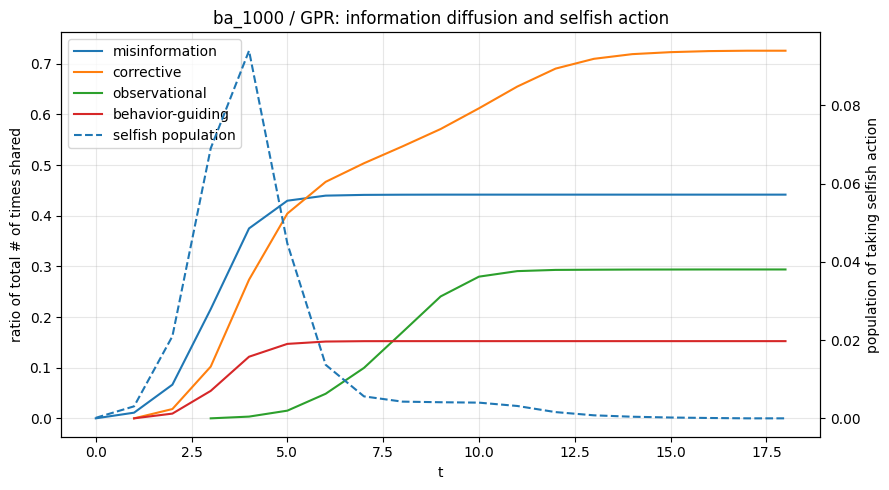

saved: optimize_behavior_ba_1000_compare/ba_1000_cmaes_main.png


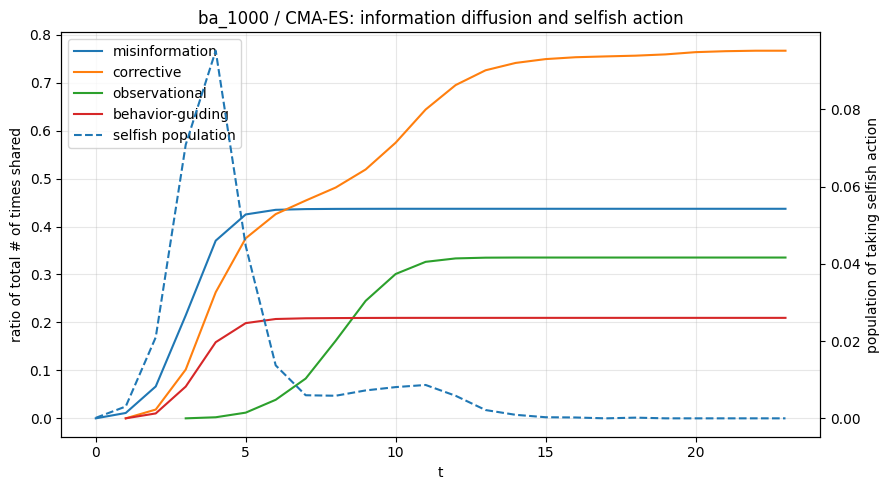

saved: optimize_behavior_ba_1000_compare/ba_1000_random_main.png


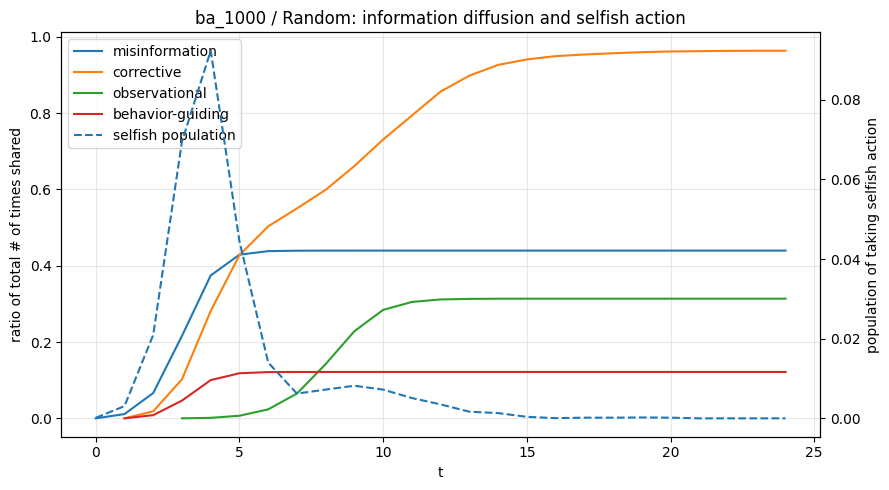

saved: optimize_behavior_ba_1000_compare/ba_1000_ga_main.png


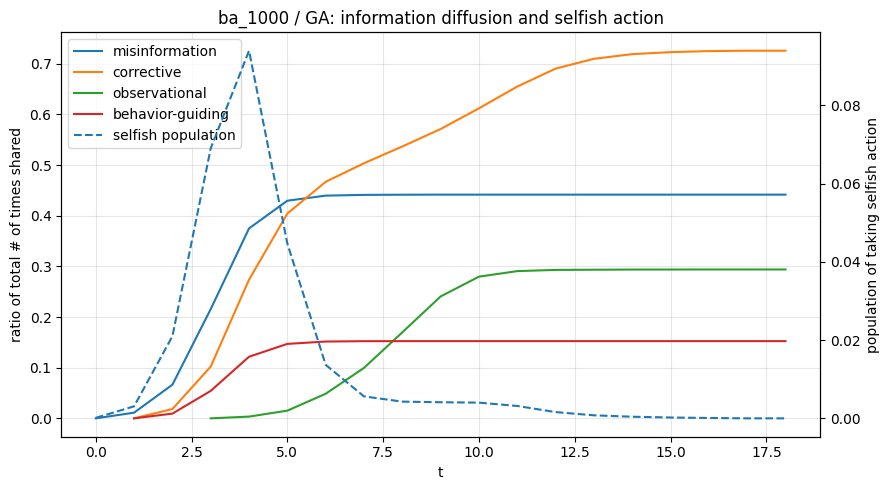

In [34]:
if SAVE_INDIVIDUAL_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for method in AVAILABLE_METHODS:
    data = methods_data[method]

    fig = plt.figure(figsize=(9, 5))
    ax = plt.gca()
    ax_r = plot_main_figure(ax, method, data)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()

    if SAVE_INDIVIDUAL_FIGURES:
        save_path = OUTPUT_DIR / f"{NETWORK_NAME}_{method}_main.png"
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print("saved:", save_path)

    plt.show()


## 3. 全手法を並べた主図を出力する

2×2 のサブプロットで、全手法を同じレイアウトで比較します。


saved: optimize_behavior_ba_1000_compare/ba_1000_methods_combined.png


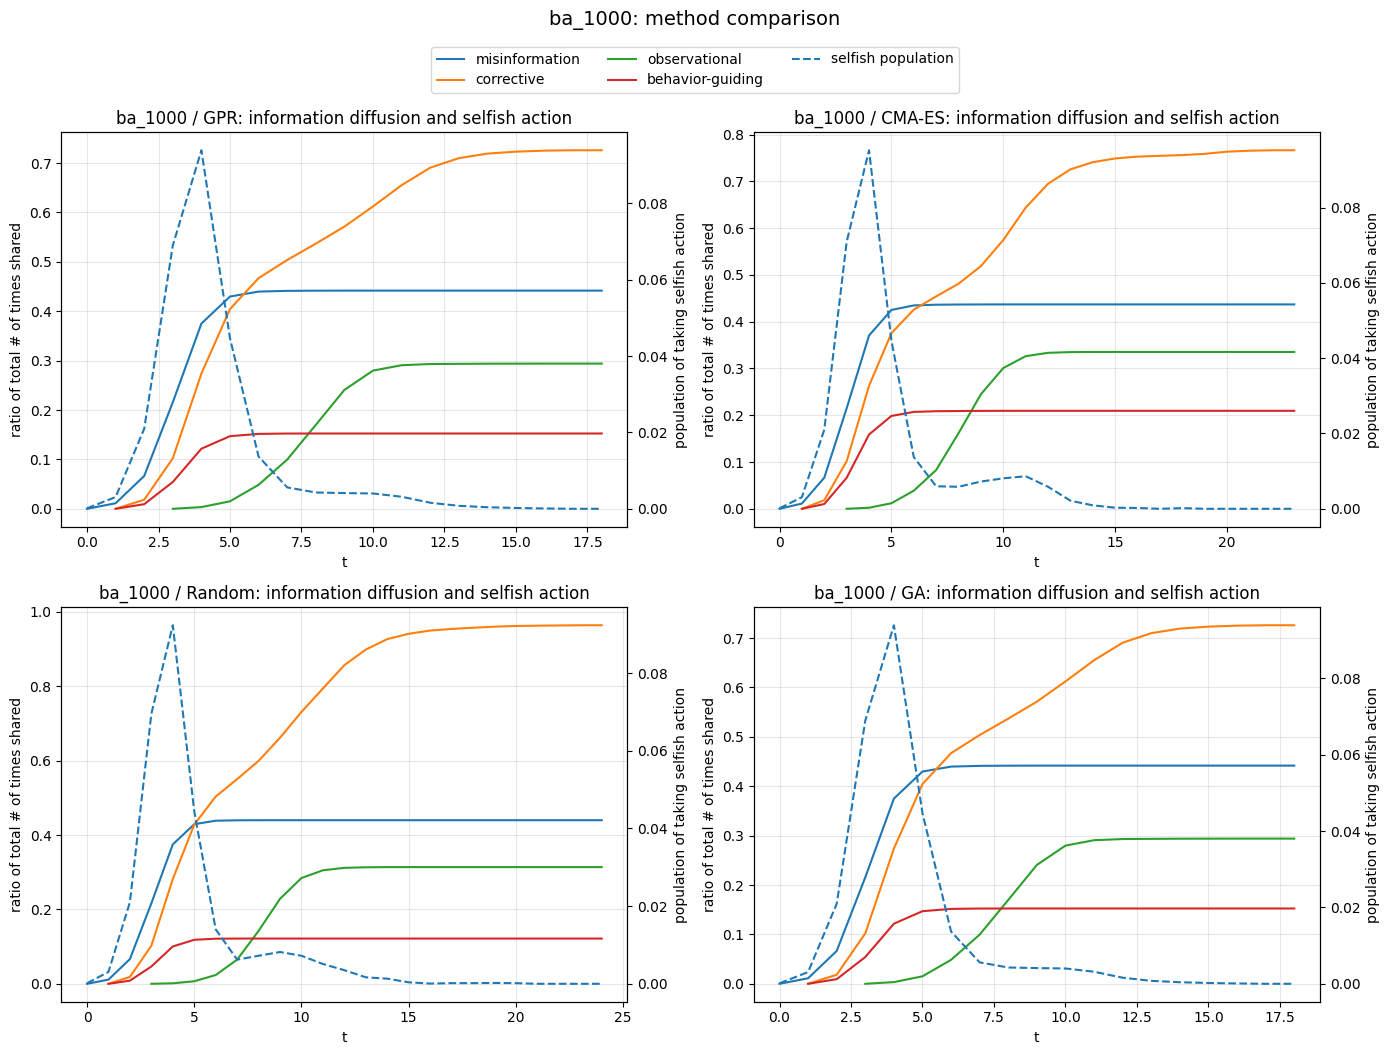

In [35]:
n_methods = len(AVAILABLE_METHODS)
ncols = 2
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows), squeeze=False)

legend_handles = None
legend_labels = None

for i, method in enumerate(AVAILABLE_METHODS):
    ax = axes.flat[i]
    data = methods_data[method]
    ax_r = plot_main_figure(ax, method, data)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_r.get_legend_handles_labels()
    if legend_handles is None:
        legend_handles = lines1 + lines2
        legend_labels = labels1 + labels2

# 余った軸を消す
for j in range(n_methods, len(axes.flat)):
    fig.delaxes(axes.flat[j])

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

fig.suptitle(f"{NETWORK_NAME}: method comparison", y=1.05, fontsize=14)
fig.tight_layout()

if SAVE_COMBINED_FIGURE:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    combined_path = OUTPUT_DIR / f"{NETWORK_NAME}_methods_combined.png"
    fig.savefig(combined_path, dpi=200, bbox_inches="tight")
    print("saved:", combined_path)

plt.show()


## 4. 補助表: info_label ごとの shared ratio だけを見やすくする

最終的な shared ratio だけを、`method × info_name` の形で見たいとき用の表です。


In [36]:
shared_ratio_pivot_df = (
    info_compare_long_df
    .select(["method_label", "info_name", "mean_total_shared_ratio"])
    .pivot(
        values="mean_total_shared_ratio",
        index="method_label",
        on="info_name"
    )
    .sort("method_label")
)

shared_ratio_pivot_df


method_label,misinformation,corrective,observational,behavior-guiding
str,f64,f64,f64,f64
"""CMA-ES""",0.43694,0.61334,0.328818,0.20943
"""GA""",0.44168,0.63924,0.2895,0.15243
"""GPR""",0.44168,0.63924,0.2895,0.15243
"""Random""",0.43981,0.825,0.311083,0.12161


## 5. 保存先の確認
このセルを実行すると、保存されたファイル一覧を確認できます。


In [37]:
if OUTPUT_DIR.exists():
    for p in sorted(OUTPUT_DIR.iterdir()):
        print(p)
else:
    print("保存先フォルダはまだ作成されていません。")


optimize_behavior_ba_1000_compare/ba_1000_cmaes_main.png
optimize_behavior_ba_1000_compare/ba_1000_ga_main.png
optimize_behavior_ba_1000_compare/ba_1000_gpr_main.png
optimize_behavior_ba_1000_compare/ba_1000_methods_combined.png
optimize_behavior_ba_1000_compare/ba_1000_random_main.png
optimize_behavior_ba_1000_compare/comparison_summary_ba_1000.csv
optimize_behavior_ba_1000_compare/info_compare_long_ba_1000.csv


## 使い方メモ

### まずやること
1. `NETWORK_NAME` を設定
2. `METHODS` を確認
3. Notebook を上から順に実行

### 保存されるもの
- `comparison_summary_<network>.csv`
- `info_compare_long_<network>.csv`
- `<network>_<method>_main.png`（手法ごとの個別図）
- `<network>_methods_combined.png`（全手法まとめ図）

### まず見るとよいもの
- `comparison_summary_df`
- `shared_ratio_pivot_df`
- 個別主図
- 全手法まとめ図


In [38]:
summary_rows = []
info_compare_rows = []

for method in AVAILABLE_METHODS:
    data = methods_data[method]
    method_label = METHOD_LABEL_MAP.get(method, method)

    pop_final_df = data["pop_final_df"]
    pop_time_mean_df = data["pop_time_mean_df"]
    info_total_df = data["info_total_summary_df"]

    row = {
        "method": method,
        "method_label": method_label,
        "mean_final_selfish_ratio": float(pop_final_df["selfish_ratio"].mean()),
        "max_final_selfish_ratio": float(pop_final_df["selfish_ratio"].max()),
        "peak_mean_selfish_ratio": float(pop_time_mean_df["mean_selfish_ratio"].max()),
    }

    for r in info_total_df.iter_rows(named=True):
        info_name = r["info_name"]
        safe_name = info_name.replace("-", "_")
        row[f"mean_total_shared_ratio_{safe_name}"] = float(r["mean_total_shared_ratio"])
        row[f"mean_total_viewed_ratio_{safe_name}"] = float(r["mean_total_viewed_ratio"])
        info_compare_rows.append({
            "method": method_label,
            "info_name": info_name,
            "mean_num_shared": float(r["mean_num_shared"]),
            "mean_total_shared_ratio": float(r["mean_total_shared_ratio"]),
            "peak_mean_selfish_ratio": float(pop_time_mean_df["mean_selfish_ratio"].max())
        })

    summary_rows.append(row)

comparison_summary_df = pl.DataFrame(summary_rows).sort("method_label")
info_compare_long_df = pl.DataFrame(info_compare_rows).sort(["method"])

with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=100):
    print(info_compare_long_df)

shape: (16, 5)
┌────────┬──────────────────┬─────────────────┬─────────────────────────┬─────────────────────────┐
│ method ┆ info_name        ┆ mean_num_shared ┆ mean_total_shared_ratio ┆ peak_mean_selfish_ratio │
│ ---    ┆ ---              ┆ ---             ┆ ---                     ┆ ---                     │
│ str    ┆ str              ┆ f64             ┆ f64                     ┆ f64                     │
╞════════╪══════════════════╪═════════════════╪═════════════════════════╪═════════════════════════╡
│ CMA-ES ┆ misinformation   ┆ 436.94          ┆ 0.43694                 ┆ 0.0952                  │
│ CMA-ES ┆ corrective       ┆ 613.34          ┆ 0.61334                 ┆ 0.0952                  │
│ CMA-ES ┆ observational    ┆ 328.818182      ┆ 0.328818                ┆ 0.0952                  │
│ CMA-ES ┆ behavior-guiding ┆ 209.43          ┆ 0.20943                 ┆ 0.0952                  │
│ GA     ┆ misinformation   ┆ 441.68          ┆ 0.44168                 ┆ 0.09394    